# Statistique bivariée

Analyse de la relation entre deux variables 

#  CAS 2 : QUALI ↔ QUANTI
## Deux modalités  
(ex : sexe → montant_panier)

*Variables* : sexe, montant_panier     
*Indicateurs* : Moyennes par catégorie  
*Graphiques* : Box plot , violin plot   
*Objectif* : Comparer deux groupes

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set(style="whitegrid")
except:
    sns = None
# chargement du jeu de données 
df = pd.read_csv("ecommerce_dataset.csv")
df.head()


,client_id,sexe,âge,revenu_mensuel,segment_age,revenu_cat,produit,canal_achat,montant_panier,panier_frequent,note_satisfaction,retour_produit,date_achat
0,1,Homme,50,3893.70,Mature,Moyen,Sport,Mobile,83.27,Non,2,Non,2023-05-28
1,2,Femme,39,2885.15,Adulte,Moyen,Électronique,Mobile,47.18,Oui,3,Non,2023-01-13
2,3,Homme,44,2369.53,Mature,Moyen,Sport,Mobile,72.28,Oui,4,Non,2023-03-13
3,4,Homme,38,3197.92,Adulte,Moyen,Électronique,Mobile,54.59,Non,3,Non,2023-05-07
4,5,Homme,20,3774.66,Jeune,Moyen,Sport,Mobile,75.30,Non,4,Non,2023-07-04


In [9]:
# Regrouper les lignes du tableau selon la colonne "sexe"
# puis analyser uniquement la colonne "montant_panier" pour chaque groupedf.groupby("sexe")["montant_panier"].agg(
    moyenne = "mean",
    mediane = "median",
    variance = "var", 
    ecarttype = "std",
    minimum = "min",
# -> lambda nécessaire ici car .agg() a besoin d'une fonction toute prête.
    Q1 = lambda x: x.quantile(0.25),
    Q2 = "median",
    Q3 = lambda x: x.quantile(0.75),
    maximum = "max",
    IQR = lambda x: x.quantile(0.75) - x.quantile(0.25),
# dispersion la + simple (sensible aux valeurs extrêmes)
    etendue = lambda x: x.max() - x.min()
)

,moyenne,mediane,variance,ecarttype,minimum,Q1,Q2,Q3,maximum,IQR,etendue
sexe,,,,,,,,,,,
Femme,87.985717,69.83,3850.995886,62.056393,10.32,45.05,69.83,111.41,664.40,66.36,654.08
Homme,98.698502,77.94,4870.335673,69.787790,11.43,51.34,77.94,124.25,929.97,72.91,918.54


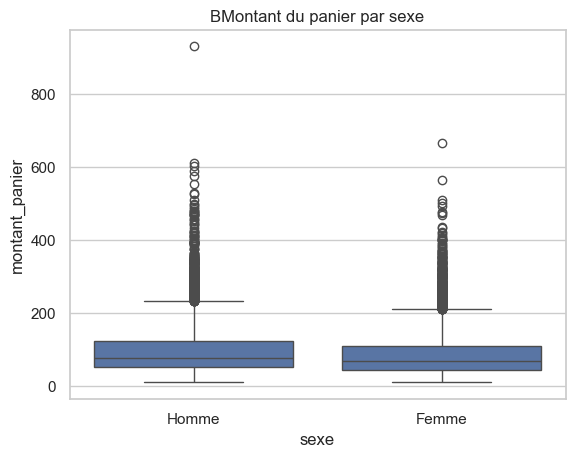

In [14]:
# nouvelle image vide
plt.figure()
# graphs plus jolis et plus simple
if sns:
    sns.boxplot(x="sexe", y="montant_panier", data=df)
# Sinon matplotlib avec plus d'étapes 
else:
    groups = [g["montant_panier"].values for _, g in df.groupby("sexe")]
    labels = df["sexe"].unique()
    plt.boxplot(groups, labels=labels)
# titre au graphique
plt.title("BMontant du panier par sexe")
plt.show()


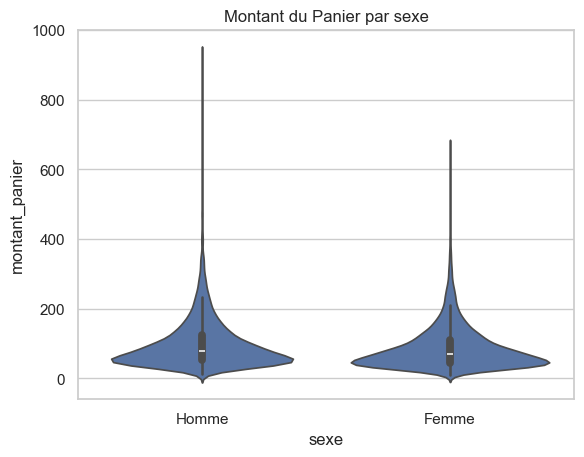

In [16]:
if sns:
    plt.figure()
    sns.violinplot(x="sexe", y="montant_panier", data=df)
    plt.title("Montant du Panier par sexe")
    plt.show()


##  Trois modalités ou plus  
(ex : segment_age → montant_panier)


*Variables* : segment_age, montant_panier     
*Indicateurs* : Moyennes par groupes  
*Graphiques* : Box plot , Bar plot   
*Objectif* : Comparer plusieurs groupes

In [24]:
# Regrouper les lignes du tableau selon la colonne "segment_age"
# Et analyser uniquement la colonne "montant_panier" pour chaque groupe
df.groupby("segment_age")["montant_panier"].agg(
    moyenne = "mean",
    mediane = "median",
    variance = "var",
    ecart_type = "std",
    minimum = "min",
# -> lambda nécessaire ici car .agg() a besoin d'une fonction toute prête
    Q1 = lambda x: x.quantile(0.25),   
    Q2 = "median",
    Q3 = lambda x: x.quantile(0.75),
    maximum = "max",
    IQR = lambda x: x.quantile(0.75) - x.quantile(0.25),
    etendue = lambda x: x.max() - x.min()
)

,moyenne,mediane,variance,ecart_type,minimum,Q1,Q2,Q3,maximum,IQR,etendue
segment_age,,,,,,,,,,,
Adulte,93.912940,73.85,4527.006478,67.283033,10.32,48.5625,73.85,117.2150,929.97,68.6525,919.65
Jeune,92.168079,73.62,4004.260479,63.279226,11.32,48.7100,73.62,115.6500,470.16,66.9400,458.84
Mature,92.670004,72.72,4302.766874,65.595479,10.37,47.7625,72.72,117.2725,603.40,69.5100,593.03
Senior,102.859880,86.46,4912.568110,70.089715,23.21,51.6550,86.46,129.4950,498.11,77.8400,474.90


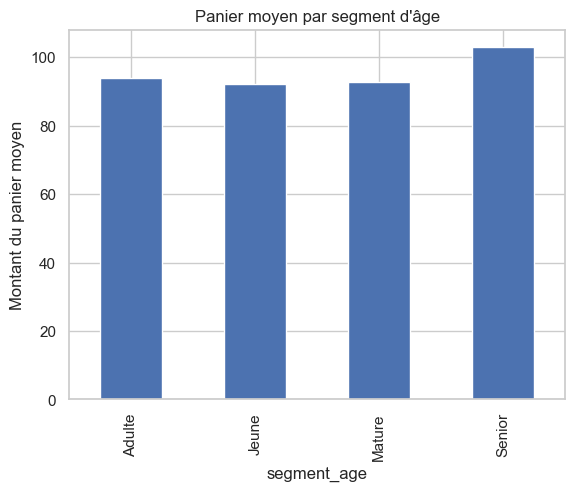

In [18]:
# montant moyen du panier regroupé par segment d'âge
means = df.groupby("segment_age")["montant_panier"].mean()
plt.figure()
#Affiche les moyennes en barres
means.plot(kind="bar")
plt.ylabel("Montant du panier moyen")
plt.title("Panier moyen par segment d'âge")
plt.show()
